In [11]:
import torchvision.transforms as transforms
from torchvision import datasets
import torch

# 이미지 변환 설정
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 데이터셋 경로 (압축 풀린 곳)
data_dir = '/content/pokemon_data/PokemonData/'

# 데이터셋 불러오기
full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms)

# 여기서 class_names가 정의됩니다!
class_names = full_dataset.classes
print(f"인식된 포켓몬 종류: {len(class_names)}개")

# 학습/테스트 데이터 분할
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

인식된 포켓몬 종류: 150개


In [22]:
def train_model(model, criterion, optimizer, num_epochs=5):
    # 딕셔너리에 val_loss 키를 미리 만들어둡니다.
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- 학습 단계 ---
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)

        # --- 검증(Validation) 단계 ---
        model.eval()
        val_loss = 0.0  # 검증 손실 초기화
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

                # 검증 손실 계산 추가
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = val_loss / len(test_dataset)
        epoch_val_acc = val_corrects.double() / len(test_dataset)

        # 결과 저장
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())

        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}')

    return history

In [13]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. 모델 설정 (실험 1: MobileNetV2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_1 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# 가중치 고정 (기존 지식 활용)
for param in model_1.parameters():
    param.requires_grad = False

# 마지막 층을 포켓몬 150종류에 맞게 수정
num_ftrs = model_1.classifier[1].in_features
model_1.classifier[1] = nn.Linear(num_ftrs, len(class_names))
model_1 = model_1.to(device)

# 2. 손실 함수 및 최적화 도구 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_1.classifier[1].parameters(), lr=0.001)

# 3. 학습 실행
print("--- 실험 1: MobileNetV2 학습 시작 ---")
# 이전에 정의한 train_model 함수를 사용합니다.
history1 = train_model(model_1, criterion, optimizer, num_epochs=5)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 122MB/s]


--- 실험 1: MobileNetV2 학습 시작 ---
Epoch 1/5 | Loss: 3.8713 | Train Acc: 0.3156 | Val Acc: 0.5924
Epoch 2/5 | Loss: 2.0119 | Train Acc: 0.7656 | Val Acc: 0.7082
Epoch 3/5 | Loss: 1.2700 | Train Acc: 0.8695 | Val Acc: 0.7493
Epoch 4/5 | Loss: 0.8994 | Train Acc: 0.9102 | Val Acc: 0.7676
Epoch 5/5 | Loss: 0.6804 | Train Acc: 0.9351 | Val Acc: 0.7852


In [15]:
# --- 실험 2: ResNet18 학습 시작 ---

# 1. 모델 설정 (ResNet18)
model_2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 가중치 고정
for param in model_2.parameters():
    param.requires_grad = False

# 마지막 층 수정 (ResNet은 fc 층을 수정합니다)
num_ftrs = model_2.fc.in_features
model_2.fc = nn.Linear(num_ftrs, len(class_names))
model_2 = model_2.to(device)

# 2. 설정 (동일하게 유지)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_2.fc.parameters(), lr=0.001)

# 3. 학습 실행
print("--- 실험 2: ResNet18 학습 시작 ---")
history2 = train_model(model_2, criterion, optimizer, num_epochs=5)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]


--- 실험 2: ResNet18 학습 시작 ---
Epoch 1/5 | Loss: 3.8859 | Train Acc: 0.2619 | Val Acc: 0.5513
Epoch 2/5 | Loss: 1.8376 | Train Acc: 0.7271 | Val Acc: 0.7185
Epoch 3/5 | Loss: 1.1021 | Train Acc: 0.8473 | Val Acc: 0.7581
Epoch 4/5 | Loss: 0.7690 | Train Acc: 0.8963 | Val Acc: 0.7793
Epoch 5/5 | Loss: 0.5872 | Train Acc: 0.9181 | Val Acc: 0.8072


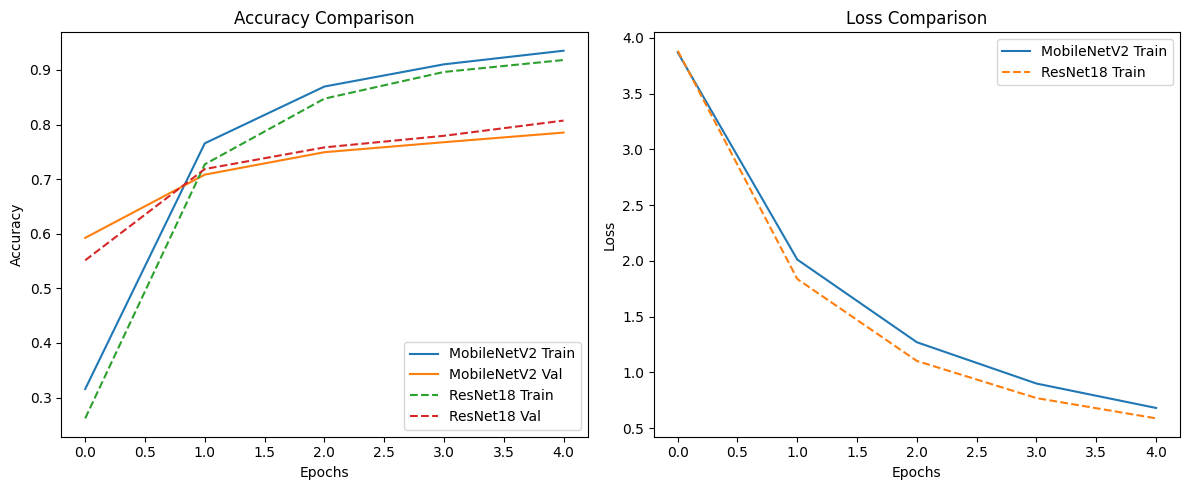

In [27]:
import matplotlib.pyplot as plt

def plot_comparison(hist1, hist2, name1="MobileNetV2", name2="ResNet18"):
    plt.figure(figsize=(12, 5))

    # 1. Accuracy 비교
    plt.subplot(1, 2, 1)
    if 'train_acc' in hist1: plt.plot(hist1['train_acc'], label=f'{name1} Train')
    if 'val_acc' in hist1: plt.plot(hist1['val_acc'], label=f'{name1} Val')
    if 'train_acc' in hist2: plt.plot(hist2['train_acc'], label=f'{name2} Train', linestyle='--')
    if 'val_acc' in hist2: plt.plot(hist2['val_acc'], label=f'{name2} Val', linestyle='--')
    plt.title('Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # 2. Loss 비교
    plt.subplot(1, 2, 2)
    if 'train_loss' in hist1: plt.plot(hist1['train_loss'], label=f'{name1} Train')
    # .get()을 사용하여 키가 없으면 None을 반환하게 하고, 데이터가 있을 때만 플롯합니다.
    if hist1.get('val_loss'): plt.plot(hist1['val_loss'], label=f'{name1} Val')

    if 'train_loss' in hist2: plt.plot(hist2['train_loss'], label=f'{name2} Train', linestyle='--')
    if hist2.get('val_loss'): plt.plot(hist2['val_loss'], label=f'{name2} Val', linestyle='--')

    plt.title('Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# 그래프 출력
plot_comparison(history1, history2)